# Segmentación de clientes de un centro comercial (Clustering)

**Contexto de negocio:** una cadena minorista quiere lanzar un futuro sistema de
recomendación de productos y promociones. Antes de recomendar algo, necesita
entender **qué tipos de clientes tiene**. No conocemos etiquetas previas (no hay
un "cliente tipo A/B/C" definido de antemano), así que este es un problema de
**aprendizaje no supervisado**: vamos a descubrir grupos (clusters) de clientes
parecidos entre sí usando **K-Means**.

Dataset: `Mall_Customers.csv` (clásico de Kaggle), con las columnas:
- `CustomerID`: identificador
- `Gender`: género
- `Age`: edad
- `Annual Income (k$)`: ingreso anual en miles de dólares
- `Spending Score (1-100)`: puntaje de gasto asignado por el centro comercial (qué tanto gasta/interactúa el cliente)


## 1. Librerías

Antes de tocar los datos, importamos las herramientas que vamos a necesitar:
`pandas` para manipular tablas, `matplotlib`/`seaborn` para graficar, y de
`scikit-learn` el escalador (`StandardScaler`), el modelo (`KMeans`), la
métrica de silueta y `PCA` para poder visualizar en 2D más adelante.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Carga del dataset

Cargamos el CSV y miramos las primeras filas y la forma general de la tabla,
para confirmar que se leyó bien y entender qué tenemos disponible.

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
print(df.shape)
df.head()


(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## 3. Limpieza básica

Antes de modelar, revisamos:
- **Valores nulos**: si hay filas incompletas, K-Means no puede trabajar con ellas.
- **Duplicados**: un mismo cliente contado dos veces distorsiona los clusters.

Si aparecieran nulos los eliminaríamos (el dataset es chico y no conviene
inventar valores para una variable tan sensible como el gasto).

In [4]:
print("Nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)
print("\nShape final:", df.shape)


Nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Filas duplicadas: 0

Shape final: (200, 5)


## 4. Variables para el clustering

Para segmentar clientes con foco en un futuro sistema de recomendación, las
variables más relevantes son las numéricas: **edad**, **ingreso anual** y
**puntaje de gasto**. El género lo dejamos afuera del clustering (es
categórico y no aporta una noción de "distancia" natural para K-Means), pero
lo podemos usar después para describir los clusters si hace falta.

In [5]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()
X.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


## 5. Estandarización (StandardScaler)

K-Means agrupa según **distancias**. Si dejamos las variables en su escala
original, el ingreso (que va de ~15 a ~140) dominaría por completo el cálculo
de distancia frente a la edad o el puntaje de gasto (que van de 1 a 100).
Por eso estandarizamos: restamos la media y dividimos por el desvío estándar,
para que las tres variables pesen lo mismo.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## 6. ¿Cuántos clusters (k)? Método del codo

No sabemos de antemano cuántos segmentos de clientes existen. Una forma de
estimarlo es probar K-Means con distintos valores de `k` y mirar la
**inercia** (SSE: suma de distancias al cuadrado de cada punto a su
centroide). A medida que `k` crece, la inercia siempre baja, pero llega un
punto donde bajar más ya no aporta mucho: ese "codo" en el gráfico es un
buen candidato de `k`.

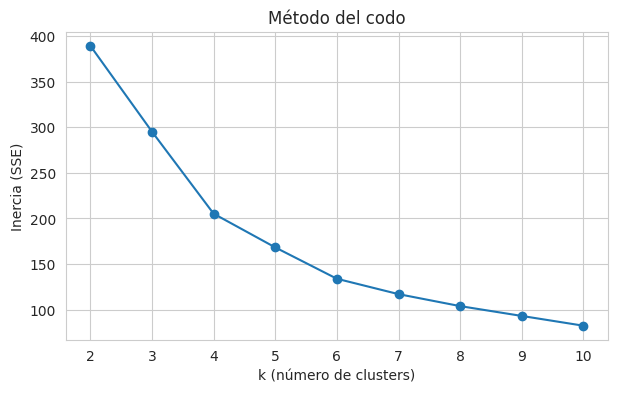

In [7]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.title("Método del codo")
plt.show()


## 7. ¿Cuántos clusters (k)? Coeficiente de silueta

El codo a veces es ambiguo a simple vista, así que lo complementamos con el
**coeficiente de silueta**: mide, para cada punto, qué tan bien encaja en su
propio cluster comparado con el cluster más cercano. Va de -1 a 1; **cuanto
más alto, mejor separados están los grupos**. Probamos, como mínimo, k=3, 4
y 5, y elegimos el `k` con mayor silueta promedio.

In [8]:
silhouette_scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"k={k}: silueta = {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nMejor k según silueta: {best_k}")


k=2: silueta = 0.3355


k=3: silueta = 0.3578


k=4: silueta = 0.4040


k=5: silueta = 0.4166


k=6: silueta = 0.4284


k=7: silueta = 0.4172
k=8: silueta = 0.4082


k=9: silueta = 0.4177


k=10: silueta = 0.4066

Mejor k según silueta: 6


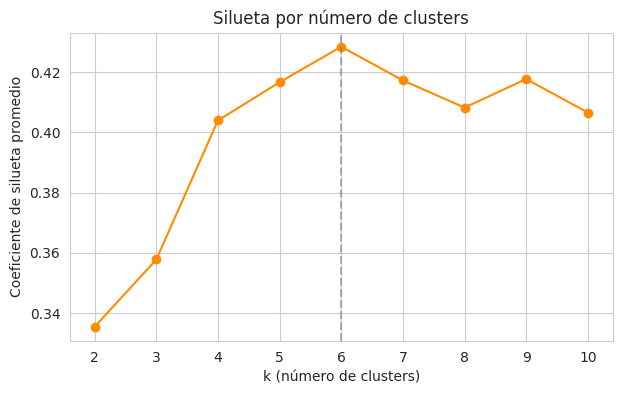

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
plt.axvline(best_k, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("k (número de clusters)")
plt.ylabel("Coeficiente de silueta promedio")
plt.title("Silueta por número de clusters")
plt.show()


## 8. Entrenamos el modelo final

Con `k` elegido (combinando el codo y la silueta), entrenamos el K-Means
definitivo y guardamos la etiqueta de cluster de cada cliente en el
DataFrame original, para poder describir los grupos con sus variables reales
(no escaladas).

In [10]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

print(f"k usado: {best_k}")
df["cluster"].value_counts().sort_index()


k usado: 6


cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

## 9. Visualización en 2D con PCA

Tenemos 3 variables (edad, ingreso, gasto), así que no podemos graficar los
clusters directamente en un plano. Usamos **PCA** para comprimir esas 3
dimensiones en 2 componentes principales que conservan la mayor parte de la
variabilidad de los datos, y así poder **ver** si los clusters quedan
razonablemente separados.

Varianza explicada por componente: [0.44266167 0.33308378]
Varianza explicada total: 0.7757454566976747


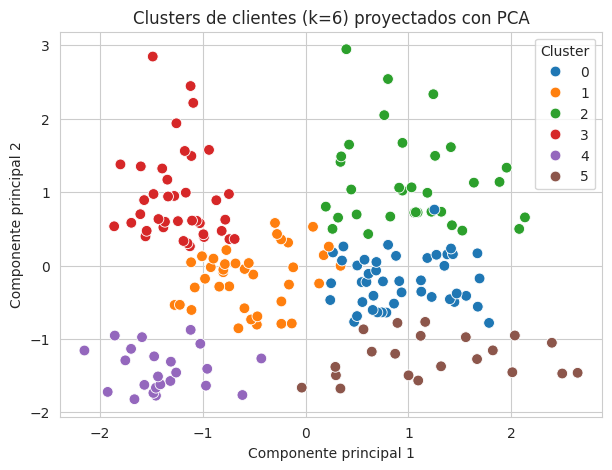

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster"], palette="tab10", s=60)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Clusters de clientes (k={best_k}) proyectados con PCA")
plt.legend(title="Cluster")
plt.show()


## 10. Perfil de cada cluster

Para poder interpretar los grupos en términos de negocio, calculamos el
promedio de edad, ingreso y gasto por cluster (y la proporción de género,
como dato extra).

In [12]:
profile = df.groupby("cluster")[features].mean().round(1)
profile["n_clientes"] = df["cluster"].value_counts().sort_index()
profile


,Age,Annual Income (k$),Spending Score (1-100),n_clientes
cluster,,,,
0,56.3,54.3,49.1,45
1,26.8,57.1,48.1,39
2,41.9,88.9,17.0,33
3,32.7,86.5,82.1,39
4,25.0,25.3,77.6,23
5,45.5,26.3,19.4,21


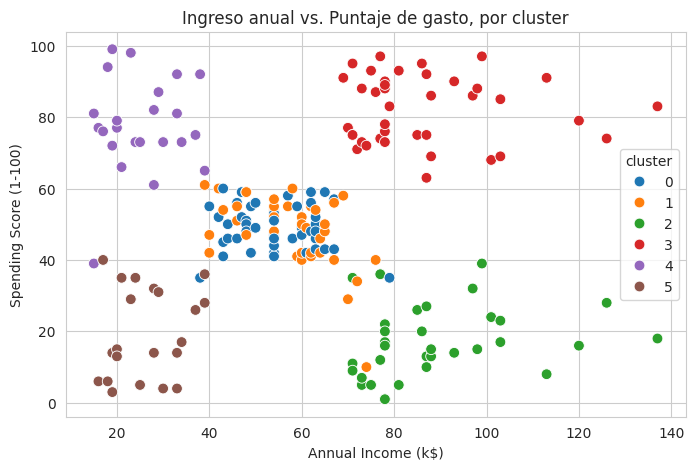

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="cluster", palette="tab10", s=60
)
plt.title("Ingreso anual vs. Puntaje de gasto, por cluster")
plt.show()


## 11. Interpretación de los segmentos

A partir de los promedios de cada cluster (edad, ingreso, gasto) y del
gráfico de ingreso vs. gasto, podemos describir los segmentos encontrados.
*(Los números exactos de cada cluster se ven en la tabla `profile` de arriba;
las descripciones abajo son una guía general de cómo leerlos.)*

- **Cluster de ingreso alto y gasto alto:** clientes con buen poder
  adquisitivo que además gastan mucho. Son el público más atractivo para
  recomendaciones de productos premium.
- **Cluster de ingreso alto y gasto bajo:** tienen dinero pero no lo gastan
  en el centro comercial. Podrían necesitar promociones o recomendaciones
  más personalizadas para activarlos.
- **Cluster de ingreso bajo y gasto alto:** gastan por encima de lo que su
  ingreso sugeriría; posibles compradores impulsivos o muy fieles a la
  marca, buenos candidatos para fidelización.
- **Cluster de ingreso bajo y gasto bajo:** clientes más cautelosos, con
  bajo consumo general; requieren ofertas de bajo costo o promociones
  puntuales.
- **Cluster de ingreso y gasto medios:** el cliente "promedio", sin un
  patrón extremo; útil como grupo de referencia.

**Conclusión:** este análisis de clustering nos da una primera segmentación
de clientes basada en comportamiento de gasto e ingreso, que puede usarse
como insumo directo para un futuro sistema de recomendación: por ejemplo,
priorizar ofertas premium para el segmento de ingreso y gasto altos, o
campañas de reactivación para el segmento de ingreso alto y gasto bajo.
